
#                                                       RetailIQ | Exploratory Data Analysis
### Author: Yuvraj
### Purpose: Understand data distributions, patterns, and 
###          prepare insights for dashboard + ML model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import warnings

warnings.filterwarnings('ignore')

In [2]:
# Style 
plt.rcParams.update({
    'figure.facecolor':  '#0d1117',   # dark background
    'axes.facecolor':    '#161b22',
    'axes.edgecolor':    '#30363d',
    'text.color':        '#c9d1d9',
    'axes.labelcolor':   '#c9d1d9',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'grid.color':        '#21262d',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     15,
})

COLORS = {
    'primary':   '#58a6ff',
    'success':   '#3fb950',
    'warning':   '#d29922',
    'danger':    '#f85149',
    'purple':    '#bc8cff',
    'orange':    '#ffa657',
    'cyan':      '#39d353',
    'palette':   ['#58a6ff','#3fb950','#ffa657','#f85149',
                  '#bc8cff','#39d353','#d29922','#ff7b72'],
}

In [ ]:
# DB Connection 
load_dotenv('../../.env')  

DB_URL = (
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

engine = create_engine(DB_URL)

In [5]:
# Test connection
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM raw.orders"))
    count = result.scalar()
    
print(f" Connected! Total orders in DB: {count:,}")

 Connected! Total orders in DB: 99,441


In [8]:
# Loading all tables from PostgreSQL 
print("Loading tables from PostgreSQL...")

df_orders   = pd.read_sql("SELECT * FROM raw.orders",   engine, 
                           parse_dates=['order_purchase_ts','order_delivered_ts',
                                        'order_estimated_ts','order_approved_ts'])
df_items    = pd.read_sql("SELECT * FROM raw.order_items", engine)
df_customers= pd.read_sql("SELECT * FROM raw.customers",   engine)
df_products = pd.read_sql("SELECT * FROM raw.products",    engine)
df_reviews  = pd.read_sql("SELECT * FROM raw.reviews",     engine,
                           parse_dates=['review_creation_date'])
df_payments = pd.read_sql("SELECT * FROM raw.payments",    engine)
df_sellers  = pd.read_sql("SELECT * FROM raw.sellers",     engine)
df_cats     = pd.read_sql("SELECT * FROM raw.category_translation", engine)

# Load our analytics views too
df_enriched = pd.read_sql("SELECT * FROM analytics.orders_enriched", engine)
df_ltv      = pd.read_sql("SELECT * FROM analytics.customer_ltv",    engine)

print("\n TABLE SIZES:")
tables = {
    'orders': df_orders, 'order_items': df_items,
    'customers': df_customers, 'products': df_products,
    'reviews': df_reviews, 'payments': df_payments,
    'sellers': df_sellers
}
for name, df in tables.items():
    print(f"  {name:<15} → {len(df):>7,} rows  |  {df.shape[1]} cols")

print(f"\n  {'orders_enriched':<15} → {len(df_enriched):>7,} rows")
print(f"  {'customer_ltv':<15} → {len(df_ltv):>7,} rows")

Loading tables from PostgreSQL...

 TABLE SIZES:
  orders          →  99,441 rows  |  8 cols
  order_items     → 112,650 rows  |  7 cols
  customers       →  99,441 rows  |  5 cols
  products        →  32,951 rows  |  9 cols
  reviews         →  99,224 rows  |  7 cols
  payments        → 103,886 rows  |  5 cols
  sellers         →   3,095 rows  |  4 cols

  orders_enriched →  99,441 rows
  customer_ltv    →  96,478 rows


### DATA QUALITY REPORT

In [9]:
# Data Quality Check 

print("DATA QUALITY REPORT")

for name, df in tables.items():
    null_pct = (df.isnull().sum() / len(df) * 100).round(2)
    null_cols = null_pct[null_pct > 0]
    
    if len(null_cols) > 0:
        print(f"\n  {name.upper()}")
        for col, pct in null_cols.items():
            bar = '█' * int(pct / 5) + '░' * (20 - int(pct / 5))
            print(f"   {col:<35} {bar} {pct:>6.2f}%")
    else:
        print(f"\n {name.upper()} — No nulls")

# ── Duplicate check ──────────────────────────────────────────
print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)
for name, df in tables.items():
    dups = df.duplicated().sum()
    status = "Good" if dups == 0 else "Duplicates found"
    print(f"  {status} {name:<20} → {dups} duplicates")

# Date range 
print("\n" + "=" )
print("DATE RANGE")
print("=")
print(f"  First order: {df_orders['order_purchase_ts'].min()}")
print(f"  Last order:  {df_orders['order_purchase_ts'].max()}")
print(f"  Span:        {(df_orders['order_purchase_ts'].max() - df_orders['order_purchase_ts'].min()).days} days")

DATA QUALITY REPORT

  ORDERS
   order_approved_ts                   ░░░░░░░░░░░░░░░░░░░░   0.16%
   order_carrier_ts                    ░░░░░░░░░░░░░░░░░░░░   1.79%
   order_delivered_ts                  ░░░░░░░░░░░░░░░░░░░░   2.98%

 ORDER_ITEMS — No nulls

 CUSTOMERS — No nulls

  PRODUCTS
   product_category_name               ░░░░░░░░░░░░░░░░░░░░   1.85%
   product_name_lenght                 ░░░░░░░░░░░░░░░░░░░░   1.85%
   product_description_lenght          ░░░░░░░░░░░░░░░░░░░░   1.85%
   product_photos_qty                  ░░░░░░░░░░░░░░░░░░░░   1.85%
   product_weight_g                    ░░░░░░░░░░░░░░░░░░░░   0.01%
   product_length_cm                   ░░░░░░░░░░░░░░░░░░░░   0.01%
   product_height_cm                   ░░░░░░░░░░░░░░░░░░░░   0.01%
   product_width_cm                    ░░░░░░░░░░░░░░░░░░░░   0.01%

  REVIEWS
   review_comment_title                █████████████████░░░  88.34%
   review_comment_message              ███████████░░░░░░░░░  58.70%

 PAYMENTS — No

### REVENUE TREND CHART

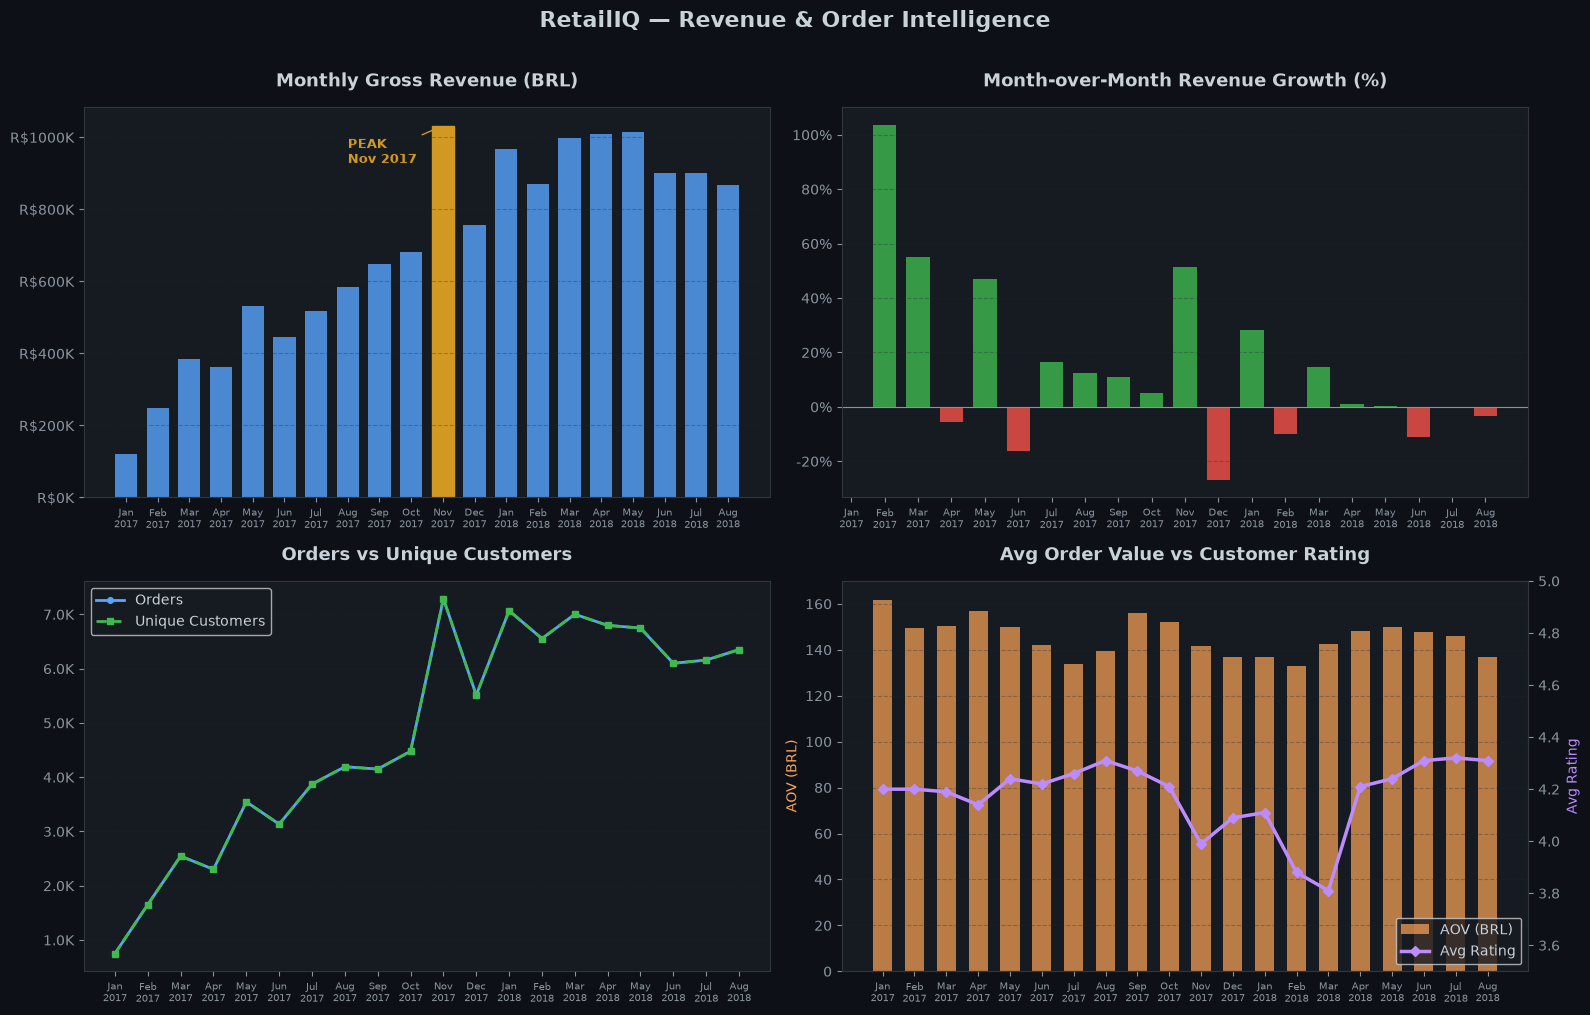

 Saved: reports/01_revenue_trend.png


In [10]:
# PLOT 1: Monthly Revenue Trend 
monthly = pd.read_sql("""
    SELECT * FROM analytics.monthly_kpis
    WHERE month >= '2017-01-01'
    ORDER BY month
""", engine, parse_dates=['month'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('RetailIQ — Revenue & Order Intelligence',
             fontsize=16, fontweight='bold', color='#c9d1d9', y=1.01)

# Panel 1: Revenue bars
ax = axes[0, 0]
bars = ax.bar(range(len(monthly)), monthly['revenue'],
              color=COLORS['primary'], alpha=0.8, width=0.7)
# Highlight peak month
peak_idx = monthly['revenue'].idxmax()
bars[peak_idx].set_color(COLORS['warning'])
bars[peak_idx].set_alpha(1.0)

ax.set_title('Monthly Gross Revenue (BRL)')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(
    monthly['month'].dt.strftime('%b\n%Y'), 
    fontsize=7, rotation=0
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x/1e3:.0f}K')
)
ax.annotate(f"PEAK\nNov 2017", 
            xy=(peak_idx, monthly['revenue'].iloc[peak_idx]),
            xytext=(peak_idx - 3, monthly['revenue'].max() * 0.9),
            arrowprops=dict(arrowstyle='->', color=COLORS['warning']),
            color=COLORS['warning'], fontsize=9, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Panel 2: MoM Growth
ax = axes[0, 1]
growth = monthly['revenue'].pct_change() * 100
colors_growth = [COLORS['success'] if g >= 0 else COLORS['danger'] 
                 for g in growth]
ax.bar(range(len(growth)), growth, color=colors_growth, alpha=0.8, width=0.7)
ax.axhline(0, color='#8b949e', linewidth=0.8)
ax.set_title('Month-over-Month Revenue Growth (%)')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(
    monthly['month'].dt.strftime('%b\n%Y'),
    fontsize=7
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.grid(axis='y', alpha=0.3)

# Panel 3: Orders vs Unique Customers
ax = axes[1, 0]
x = range(len(monthly))
ax.plot(x, monthly['orders'], color=COLORS['primary'],
        linewidth=2, marker='o', markersize=4, label='Orders')
ax.plot(x, monthly['customers'], color=COLORS['success'],
        linewidth=2, marker='s', markersize=4, label='Unique Customers',
        linestyle='--')
ax.set_title('Orders vs Unique Customers')
ax.set_xticks(x)
ax.set_xticklabels(monthly['month'].dt.strftime('%b\n%Y'), fontsize=7)
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.1f}K'))

# Panel 4: Avg Order Value + Rating dual axis
ax = axes[1, 1]
ax2 = ax.twinx()
ax.bar(x, monthly['aov'], color=COLORS['orange'], alpha=0.7, 
       width=0.6, label='AOV (BRL)')
ax2.plot(x, monthly['avg_rating'], color=COLORS['purple'],
         linewidth=2.5, marker='D', markersize=5, label='Avg Rating')
ax.set_title('Avg Order Value vs Customer Rating')
ax.set_xticks(x)
ax.set_xticklabels(monthly['month'].dt.strftime('%b\n%Y'), fontsize=7)
ax.set_ylabel('AOV (BRL)', color=COLORS['orange'])
ax2.set_ylabel('Avg Rating', color=COLORS['purple'])
ax2.set_ylim(3.5, 5.0)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../../reports/01_revenue_trend.png', 
            dpi=150, bbox_inches='tight', 
            facecolor='#0d1117')
plt.show()
print(" Saved: reports/01_revenue_trend.png")

### CUSTOMER SEGMENTATION CHART

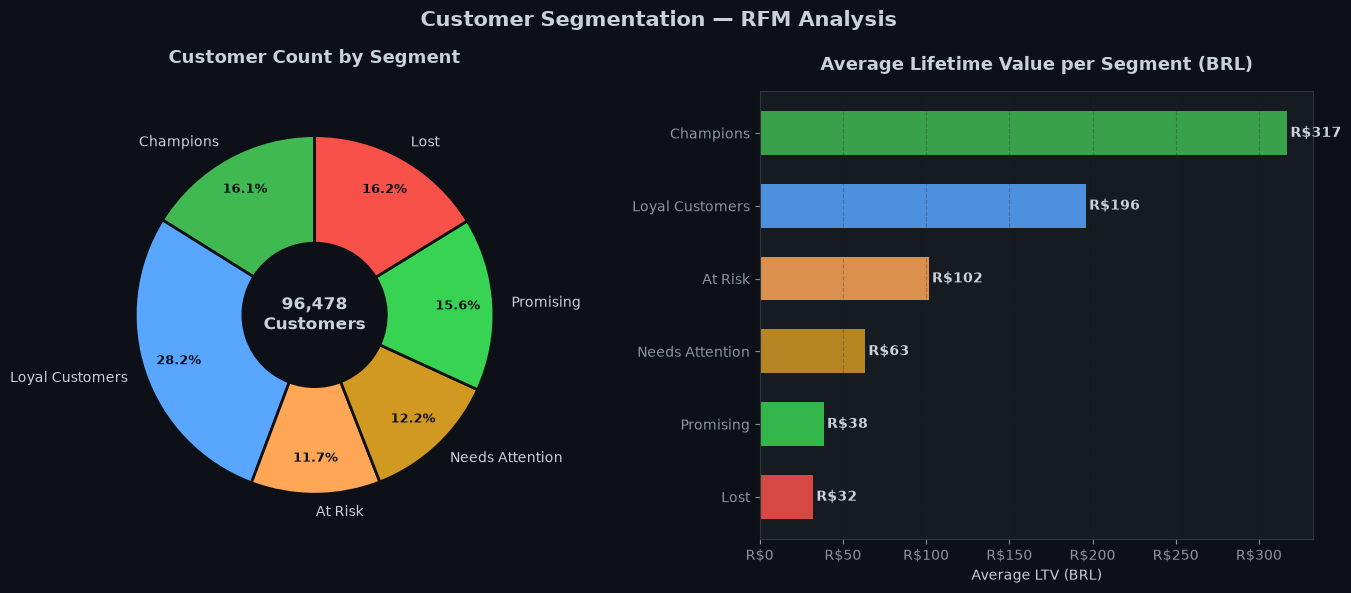

 Saved: reports/02_customer_segments.png


In [11]:
# PLOT 2: Customer Segments 
segments = pd.read_sql("""
    WITH rfm_base AS (
        SELECT customer_id,
               MAX(order_purchase_ts)                           AS last_order,
               COUNT(DISTINCT o.order_id)                       AS frequency,
               SUM(oi.price)                                    AS monetary,
               EXTRACT(DAY FROM (
                   MAX(order_purchase_ts) - 
                   (SELECT MAX(order_purchase_ts) FROM raw.orders)
               )) * -1                                          AS recency_days
        FROM raw.orders o
        JOIN raw.order_items oi ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY customer_id
    ),
    scored AS (
        SELECT *,
            NTILE(5) OVER (ORDER BY recency_days DESC)  AS r,
            NTILE(5) OVER (ORDER BY frequency)          AS f,
            NTILE(5) OVER (ORDER BY monetary)           AS m
        FROM rfm_base
    )
    SELECT
        CASE
            WHEN (r+f+m) >= 13 THEN 'Champions'
            WHEN (r+f+m) >= 10 AND f >= 3 THEN 'Loyal Customers'
            WHEN r >= 4 AND f <= 2 THEN 'Promising'
            WHEN r <= 2 AND (f+m) >= 6 THEN 'At Risk'
            WHEN (r+f+m) <= 5 THEN 'Lost'
            ELSE 'Needs Attention'
        END AS segment,
        COUNT(*) AS count,
        ROUND(AVG(monetary)::NUMERIC, 2) AS avg_ltv,
        ROUND(AVG(recency_days)::NUMERIC, 0) AS avg_recency
    FROM scored
    GROUP BY 1
    ORDER BY avg_ltv DESC
""", engine)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Customer Segmentation — RFM Analysis',
             fontsize=15, fontweight='bold', color='#c9d1d9')

seg_colors = {
    'Champions':       COLORS['success'],
    'Loyal Customers': COLORS['primary'],
    'Promising':       COLORS['cyan'],
    'Needs Attention': COLORS['warning'],
    'At Risk':         COLORS['orange'],
    'Lost':            COLORS['danger'],
}

# Left: Donut chart — customer count
ax = axes[0]
colors = [seg_colors.get(s, '#58a6ff') for s in segments['segment']]
wedges, texts, autotexts = ax.pie(
    segments['count'],
    labels=segments['segment'],
    colors=colors,
    autopct='%1.1f%%',
    pctdistance=0.8,
    startangle=90,
    wedgeprops=dict(width=0.6, edgecolor='#0d1117', linewidth=2)
)
for t in texts:
    t.set_color('#c9d1d9')
    t.set_fontsize(10)
for at in autotexts:
    at.set_color('#0d1117')
    at.set_fontweight('bold')
    at.set_fontsize(9)

# Center label
ax.text(0, 0, f"{segments['count'].sum():,}\nCustomers",
        ha='center', va='center',
        color='#c9d1d9', fontsize=12, fontweight='bold')
ax.set_title('Customer Count by Segment', pad=20)

# Right: LTV comparison bars
ax = axes[1]
bars = ax.barh(segments['segment'], segments['avg_ltv'],
               color=colors, alpha=0.85, height=0.6)

for bar, val in zip(bars, segments['avg_ltv']):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f'R${val:.0f}', va='center', fontsize=10,
            color='#c9d1d9', fontweight='bold')

ax.set_title('Average Lifetime Value per Segment (BRL)')
ax.set_xlabel('Average LTV (BRL)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}'))
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../../reports/02_customer_segments.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print(" Saved: reports/02_customer_segments.png")

### DELIVERY IMPACT CHART

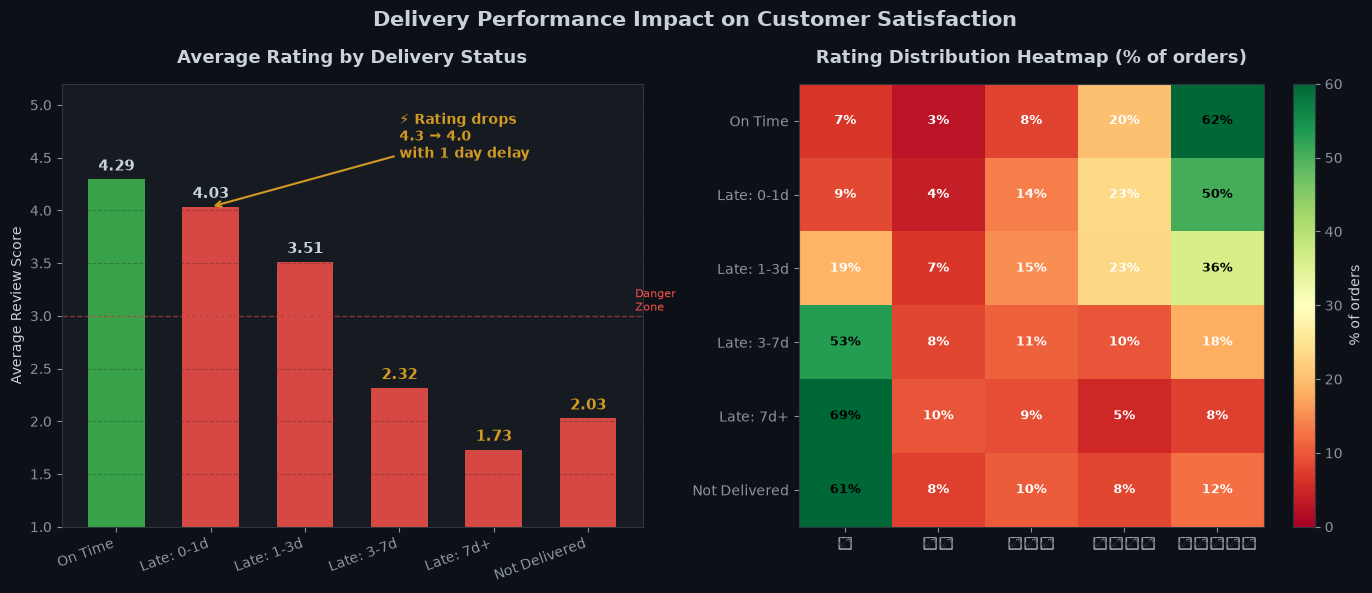

 Saved: reports/03_delivery_impact.png


In [12]:
# PLOT 3: Delivery Impact on Ratings 
delivery = pd.read_sql("""
    SELECT
        CASE
            WHEN o.order_delivered_ts IS NULL THEN 'Not Delivered'
            WHEN o.order_delivered_ts <= o.order_estimated_ts THEN 'On Time'
            WHEN o.order_delivered_ts <= o.order_estimated_ts + INTERVAL '1 day' 
                THEN 'Late: 0-1d'
            WHEN o.order_delivered_ts <= o.order_estimated_ts + INTERVAL '3 days' 
                THEN 'Late: 1-3d'
            WHEN o.order_delivered_ts <= o.order_estimated_ts + INTERVAL '7 days' 
                THEN 'Late: 3-7d'
            ELSE 'Late: 7d+'
        END AS delivery_bucket,
        r.review_score
    FROM raw.orders o
    JOIN raw.reviews r ON o.order_id = r.order_id
    WHERE o.order_status IN ('delivered', 'shipped')
      AND r.review_score IS NOT NULL
""", engine)

bucket_order = ['On Time', 'Late: 0-1d', 'Late: 1-3d', 
                'Late: 3-7d', 'Late: 7d+', 'Not Delivered']
delivery['delivery_bucket'] = pd.Categorical(
    delivery['delivery_bucket'], categories=bucket_order, ordered=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Delivery Performance Impact on Customer Satisfaction',
             fontsize=15, fontweight='bold', color='#c9d1d9')

# Left: Avg rating by bucket
avg_ratings = delivery.groupby('delivery_bucket', observed=True)['review_score'].mean()
bar_colors = [COLORS['success'] if b == 'On Time' else COLORS['danger'] 
              for b in avg_ratings.index]

ax = axes[0]
bars = ax.bar(range(len(avg_ratings)), avg_ratings.values,
              color=bar_colors, alpha=0.85, width=0.6)
ax.set_xticks(range(len(avg_ratings)))
ax.set_xticklabels(avg_ratings.index, rotation=20, ha='right', fontsize=10)
ax.set_ylim(1, 5.2)
ax.set_ylabel('Average Review Score')
ax.set_title('Average Rating by Delivery Status')

for bar, val in zip(bars, avg_ratings.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f'{val:.2f}', ha='center', va='bottom',
            fontweight='bold', fontsize=11,
            color=COLORS['warning'] if val < 3 else '#c9d1d9')

# KEY FINDING annotation
ax.annotate(
    f'⚡ Rating drops\n{avg_ratings["On Time"]:.1f} → {avg_ratings["Late: 0-1d"]:.1f}\nwith 1 day delay',
    xy=(1, avg_ratings["Late: 0-1d"]),
    xytext=(3, 4.5),
    arrowprops=dict(arrowstyle='->', color=COLORS['warning'], lw=1.5),
    color=COLORS['warning'], fontsize=10, fontweight='bold'
)
ax.axhline(3.0, color=COLORS['danger'], linewidth=1, linestyle='--', alpha=0.5)
ax.text(5.5, 3.05, 'Danger\nZone', color=COLORS['danger'], fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Right: Rating distribution heatmap
rating_pivot = (delivery.groupby(['delivery_bucket', 'review_score'], observed=True)
                .size()
                .unstack(fill_value=0))
rating_pct = rating_pivot.div(rating_pivot.sum(axis=1), axis=0) * 100

ax = axes[1]
im = ax.imshow(rating_pct.values, cmap='RdYlGn', aspect='auto',
               vmin=0, vmax=60)

ax.set_xticks(range(5))
ax.set_xticklabels(['⭐', '⭐⭐', '⭐⭐⭐', '⭐⭐⭐⭐', '⭐⭐⭐⭐⭐'])
ax.set_yticks(range(len(rating_pct.index)))
ax.set_yticklabels(rating_pct.index)
ax.set_title('Rating Distribution Heatmap (% of orders)')

for i in range(len(rating_pct.index)):
    for j in range(5):
        val = rating_pct.values[i, j]
        ax.text(j, i, f'{val:.0f}%',
                ha='center', va='center',
                color='black' if val > 30 else 'white',
                fontweight='bold', fontsize=9)

plt.colorbar(im, ax=ax, label='% of orders')
plt.tight_layout()
plt.savefig('../../reports/03_delivery_impact.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print(" Saved: reports/03_delivery_impact.png")

### CHURN FEATURE ENGINEERING (ML PREPARATION)

Building churn features...
Reference date: 2018-08-29

CHURN ANALYSIS SUMMARY
Total customers:    96,478
Churned (180d+):    57,459  (59.6%)
Retained:           39,019  (40.4%)
Features created: 16

 Saved churn features: data/sample/churn_features.csv


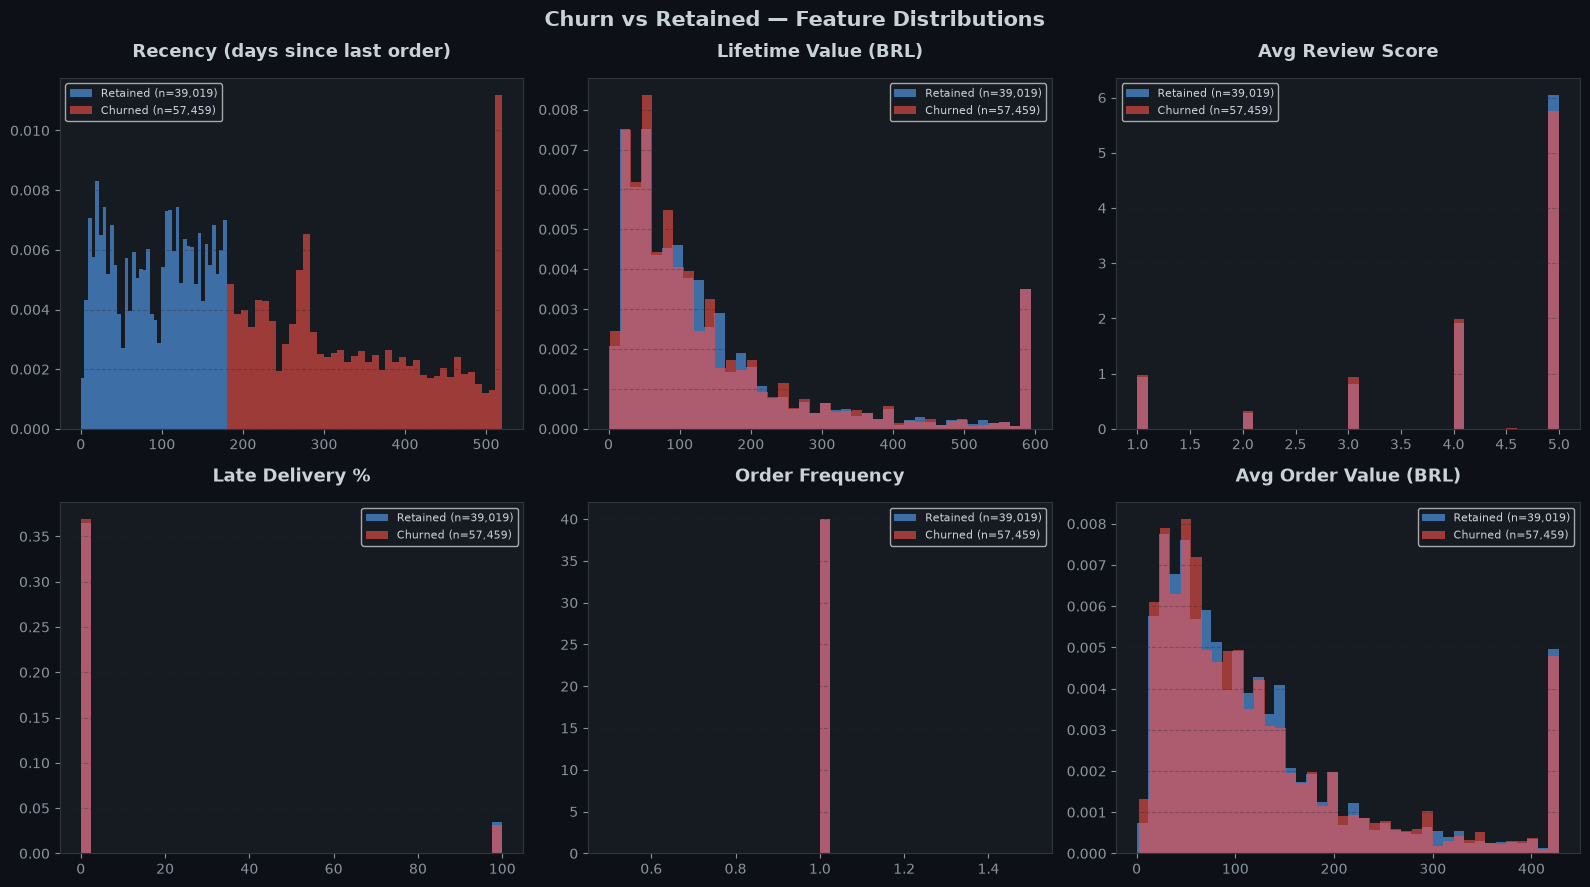

 Saved: reports/04_churn_distributions.png

Churn features shape: (96478, 19)


In [13]:
# CHURN FEATURE ENGINEERING 


print("Building churn features...")

# Master dataset from enriched view
df_churn_base = pd.read_sql("""
    SELECT
        oe.customer_id,
        oe.order_id,
        oe.order_purchase_ts,
        oe.order_revenue,
        oe.freight_cost,
        oe.review_score,
        oe.delivery_status,
        oe.delay_hours,
        oe.payment_type,
        oe.installments,
        oe.item_count,
        p.product_category_name,
        c.customer_state
    FROM analytics.orders_enriched oe
    LEFT JOIN raw.order_items oi ON oe.order_id = oi.order_id
    LEFT JOIN raw.products p   ON oi.product_id = p.product_id
    LEFT JOIN raw.customers c  ON oe.customer_id = c.customer_id
    WHERE oe.order_status = 'delivered'
""", engine, parse_dates=['order_purchase_ts'])

reference_date = df_churn_base['order_purchase_ts'].max()
print(f"Reference date: {reference_date.date()}")

# Aggregate per customer 
churn_features = df_churn_base.groupby('customer_id').agg(
    # RFM base
    recency_days       = ('order_purchase_ts', 
                          lambda x: (reference_date - x.max()).days),
    frequency          = ('order_id', 'nunique'),
    monetary           = ('order_revenue', 'sum'),
    avg_order_value    = ('order_revenue', 'mean'),
    
    # Satisfaction signals
    avg_review_score   = ('review_score', 'mean'),
    min_review_score   = ('review_score', 'min'),
    pct_bad_reviews    = ('review_score', 
                          lambda x: (x <= 2).mean() * 100),
    
    # Delivery signals
    late_delivery_pct  = ('delivery_status',
                          lambda x: (x == 'Late').mean() * 100),
    avg_delay_hours    = ('delay_hours', 
                          lambda x: x[x > 0].mean() 
                          if (x > 0).any() else 0),
    
    # Order behavior
    avg_item_count     = ('item_count', 'mean'),
    avg_freight        = ('freight_cost', 'mean'),
    freight_ratio      = ('freight_cost',
                          lambda x: (x / df_churn_base.loc[
                              x.index, 'order_revenue'
                          ].replace(0, np.nan)).mean() * 100),
    
    # Payment behavior
    pct_credit_card    = ('payment_type',
                          lambda x: (x == 'credit_card').mean() * 100),
    avg_installments   = ('installments', 'mean'),
    
    # Customer tenure
    customer_age_days  = ('order_purchase_ts',
                          lambda x: (x.max() - x.min()).days),
    first_order        = ('order_purchase_ts', 'min'),
    last_order         = ('order_purchase_ts', 'max'),
).reset_index()

# Fill NaN values 
churn_features['avg_delay_hours']  = churn_features['avg_delay_hours'].fillna(0)
churn_features['avg_review_score'] = churn_features['avg_review_score'].fillna(3.0)
churn_features['min_review_score'] = churn_features['min_review_score'].fillna(3.0)

# CHURN LABEL 
# Definition: No order in last 180 days = churned
CHURN_THRESHOLD = 180
churn_features['churned'] = (
    churn_features['recency_days'] > CHURN_THRESHOLD
).astype(int)

# Stats
total     = len(churn_features)
churned   = churn_features['churned'].sum()
retained  = total - churned
churn_rate = churned / total * 100

print(f"\n{'='*50}")
print(f"CHURN ANALYSIS SUMMARY")
print(f"{'='*50}")
print(f"Total customers:  {total:>8,}")
print(f"Churned (180d+):  {churned:>8,}  ({churn_rate:.1f}%)")
print(f"Retained:         {retained:>8,}  ({100-churn_rate:.1f}%)")
print(f"Features created: {len(churn_features.columns) - 3}")  # minus id, dates, label

# Save for ML notebook 
churn_features.to_csv('../../data/sample/churn_features.csv', index=False)
print(f"\n Saved churn features: data/sample/churn_features.csv")

# Feature Distribution Plot 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Churn vs Retained — Feature Distributions',
             fontsize=15, fontweight='bold', color='#c9d1d9')

churned_df  = churn_features[churn_features['churned'] == 1]
retained_df = churn_features[churn_features['churned'] == 0]

features_to_plot = [
    ('recency_days',    'Recency (days since last order)'),
    ('monetary',        'Lifetime Value (BRL)'),
    ('avg_review_score','Avg Review Score'),
    ('late_delivery_pct','Late Delivery %'),
    ('frequency',       'Order Frequency'),
    ('avg_order_value', 'Avg Order Value (BRL)'),
]

for ax, (feat, title) in zip(axes.flat, features_to_plot):
    # Clip outliers for visibility
    cap = churn_features[feat].quantile(0.95)
    c_vals = churned_df[feat].clip(upper=cap)
    r_vals = retained_df[feat].clip(upper=cap)
    
    ax.hist(r_vals, bins=40, alpha=0.6, color=COLORS['primary'],
            density=True, label=f'Retained (n={len(retained_df):,})')
    ax.hist(c_vals, bins=40, alpha=0.6, color=COLORS['danger'],
            density=True, label=f'Churned (n={len(churned_df):,})')
    
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../../reports/04_churn_distributions.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print(" Saved: reports/04_churn_distributions.png")
print(f"\nChurn features shape: {churn_features.shape}")

##### SAMPLE DATA FOR GITHUB

In [14]:
#  Create sample datasets for GitHub demo 


print("Creating sample datasets for GitHub...")

sample_size = 500

# Get 500 random order_ids
sample_order_ids = df_orders['order_id'].sample(
    sample_size, random_state=42
).tolist()
ids_str = "', '".join(sample_order_ids)

# Sample slices
for name, df, id_col in [
    ('orders',      df_orders,   'order_id'),
    ('order_items', df_items,    'order_id'),
    ('reviews',     df_reviews,  'order_id'),
    ('payments',    df_payments, 'order_id'),
]:
    if id_col == 'order_id':
        sample = df[df['order_id'].isin(sample_order_ids)]
    else:
        sample = df.sample(min(sample_size, len(df)), random_state=42)
    
    sample.to_csv(f'../../data/sample/sample_{name}.csv', index=False)
    print(f"   Created sample_{name}.csv — {len(sample)} rows")

# Customers sample
sample_cids = df_orders[df_orders['order_id'].isin(sample_order_ids)]['customer_id']
df_customers[df_customers['customer_id'].isin(sample_cids)]\
    .to_csv('../../data/sample/sample_customers.csv', index=False)

print("\n All sample files created in data/sample/")
print("   These are safe to commit to GitHub (small size).")

Creating sample datasets for GitHub...
   Created sample_orders.csv — 500 rows
   Created sample_order_items.csv — 577 rows
   Created sample_reviews.csv — 500 rows
   Created sample_payments.csv — 509 rows

 All sample files created in data/sample/
   These are safe to commit to GitHub (small size).
